/tmp/ipykernel_862625/4220440599.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


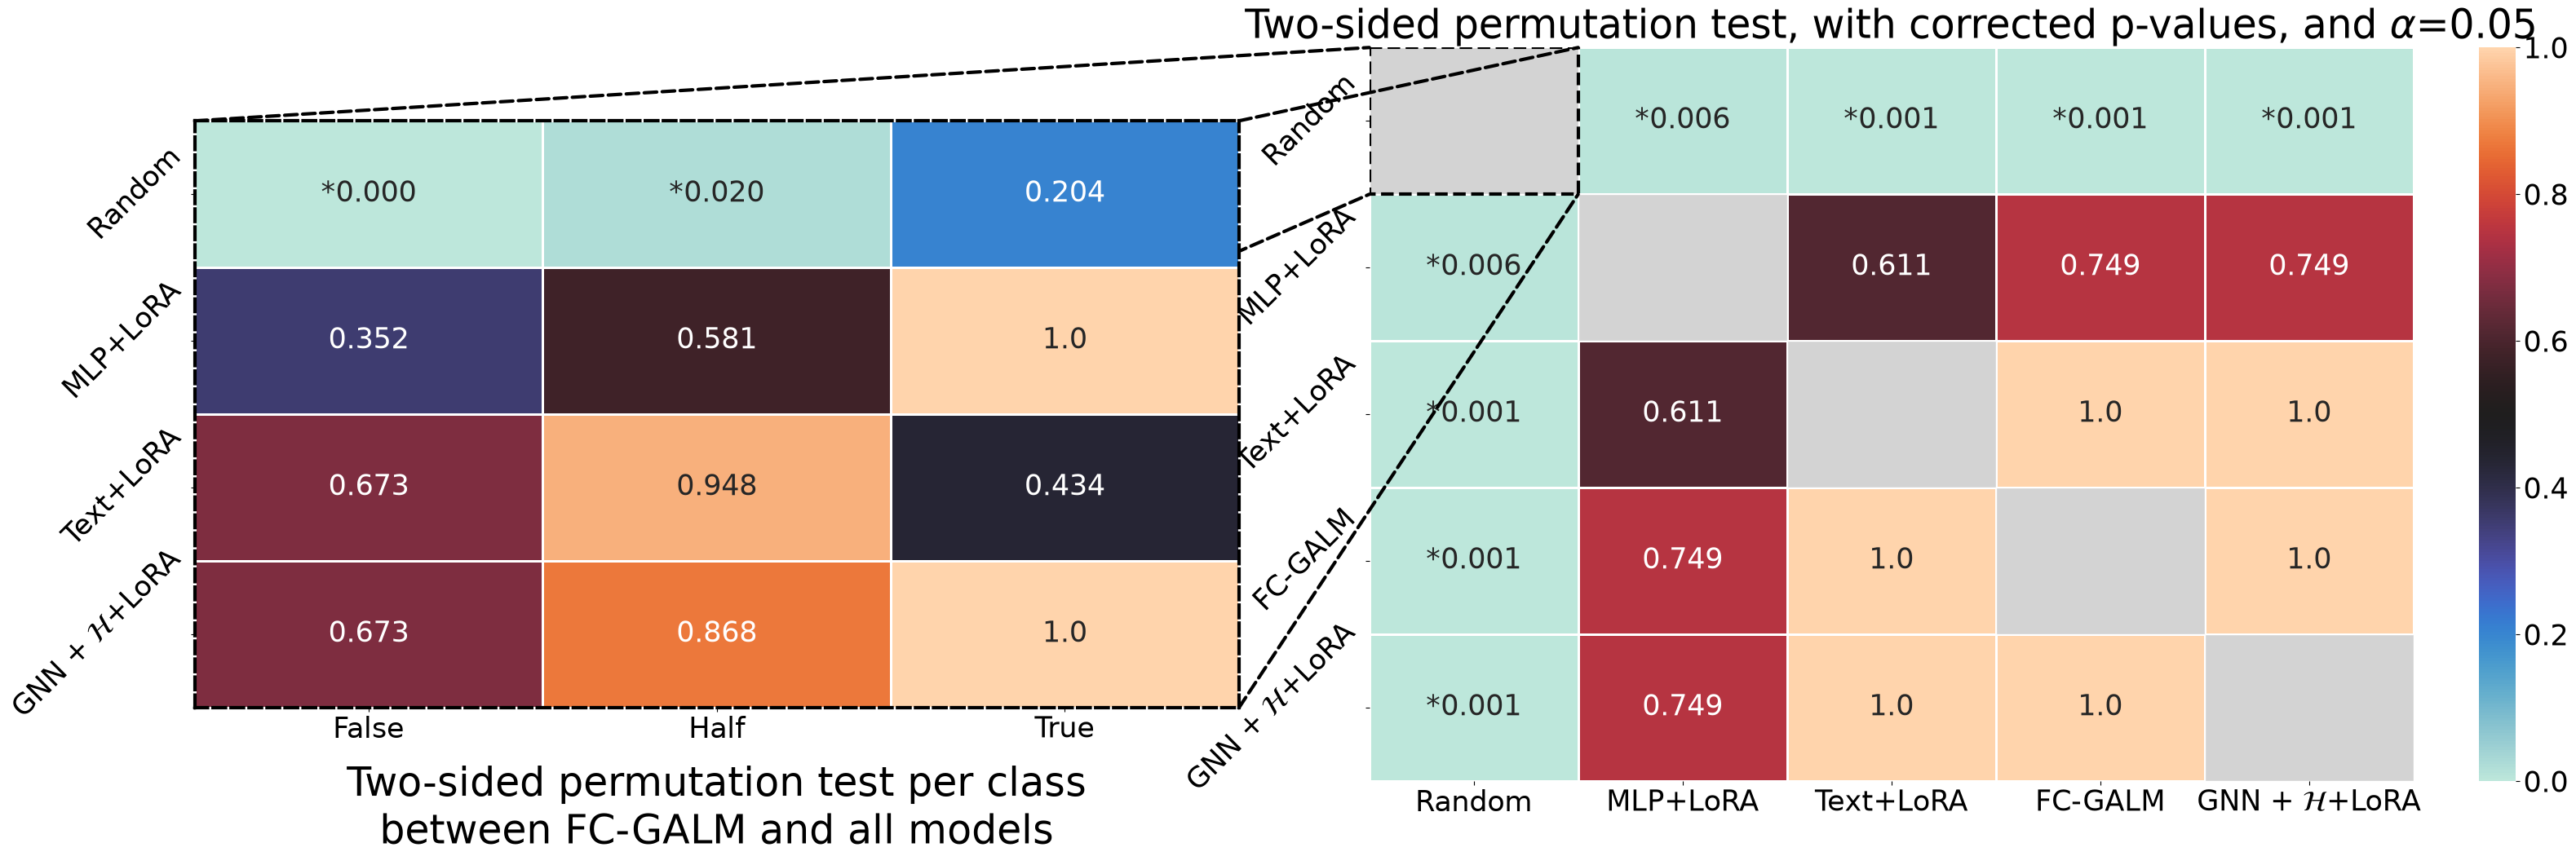

In [ ]:
import pickle
from matplotlib.patches import ConnectionPatch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

np.random.seed(42)
dataset = "RAWFC"

stats_rawfc = pickle.load(open(f"all_p_values_{dataset}.pkl", "rb"))
stats_rawfc_fcgalm_versus = pickle.load(open(f"all_p_values_{dataset}_fcgalm_perclass.pkl", "rb"))
classification_lab2id = json.load(
	open(
		f"predicted_test_samples/FcGalm/{dataset}/classification_lab2id_map.json",
		"r",
	)
)
model_name_map = {
	"FcGalm": "FC-GALM",
	"GnnOnly_gnn_lora_hetero": r"GNN + $\mathcal{H}$+LoRA",
	"Mlp_mlp_lora": "MLP+LoRA",
	"TextOnly_text_lora": "Text+LoRA",
	"TextOnly": "Text",
	"random_classifier": "Random",
}

###### BIG HEATMAP - MODEL VS MODEL

unique_models = set()
for pair in stats_rawfc.keys():
	pair = pair.split("---")
	unique_models |= set([pair[0]])
	unique_models |= set([pair[1]])

mapped_unique_names = [model_name_map[name] for name in unique_models]
p_val_matrix = np.zeros((len(unique_models), len(unique_models)))
annotation = np.empty((len(unique_models), len(unique_models)), dtype=np.ufunc)
mask = ~np.tril(np.ones_like(annotation, dtype=bool))

# create value and annotation matrices to use for display
for i, model_a in enumerate(unique_models):
	for j, model_b in enumerate(unique_models):
		if model_a == model_b:
			p_val_matrix[i, j] = np.nan
			continue

		pair = f"{model_a}---{model_b}"
		if pair not in stats_rawfc.keys():
			# continue
			pair_inverted = f"{model_b}---{model_a}"
			pair = pair_inverted
		pair_stats = stats_rawfc[pair]
		corrected_p_val = pair_stats["corrected_p"]
		if corrected_p_val < 0.05:
			display_p_val = f"*{corrected_p_val:0.3f}"
		else:
			display_p_val = str(round(corrected_p_val, 3))

		annotation[i, j] = display_p_val
		p_val_matrix[i, j] = corrected_p_val

fig = plt.figure(figsize=(16, 9))
ax_big = fig.add_axes([1, 1, 1, 1])  # ax of model vs. model
ax_inner = fig.add_axes([0.1, 1.1, 0.8, 0.8])  # ax of fcgalm vs models per class

big_heatmap = sns.heatmap(
	p_val_matrix,
	annot=annotation,
	xticklabels=mapped_unique_names,
	yticklabels=mapped_unique_names,
	fmt="",
	vmin=0,
	vmax=1,
	linewidths=1,
	annot_kws={"fontsize": 25},
	cmap=sns.cm.icefire,
	ax=ax_big,
)
cbar = big_heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=25)

# mask main diagonal
for idx in range(len(unique_models)):
	big_heatmap.add_patch(
		plt.Rectangle((idx, idx), 1, 1, facecolor="lightgray", edgecolor="white", linewidth=1)
	)

ax_big.set_title(
	rf"Two-sided permutation test, with corrected p-values, and $\alpha$={0.05}", fontsize=35
)

###### SMALL HEATMAP - FCGALM VS MODEL PER CLASS

inner_unique_names = unique_models.copy()
inner_unique_names.remove("FcGalm")
num_classes = len(list(stats_rawfc_fcgalm_versus["random_classifier"].keys()))
inner_mapped_unique_names = [model_name_map[l] for l in inner_unique_names]
p_val_matrix_inner = np.zeros((len(inner_unique_names), num_classes))
annotation_inner = np.empty(
	(
		len(inner_unique_names),
		num_classes,
	),
	dtype=np.ufunc,
)

for i, model_lab in enumerate(inner_unique_names):
	for j, class_lab in enumerate(classification_lab2id.keys()):
		corrected_p_val_class = stats_rawfc_fcgalm_versus[model_lab][class_lab]
		if corrected_p_val_class < 0.05:
			display_p_val = f"*{corrected_p_val_class:0.3f}"
		else:
			display_p_val = str(round(corrected_p_val_class, 3))

		annotation_inner[i, j] = display_p_val
		p_val_matrix_inner[i, j] = corrected_p_val_class

inner_hm_x_class_labs = [l.title() for l in list(classification_lab2id.keys())]

inner_heatmap = sns.heatmap(
	p_val_matrix_inner,
	ax=ax_inner,
	fmt="",
	vmin=0,
	vmax=1,
	annot=annotation_inner,
	linewidths=1,
	xticklabels=inner_hm_x_class_labs,
	annot_kws={"fontsize": 25},
	yticklabels=inner_mapped_unique_names,
	cmap=sns.cm.icefire,
	# cbar_kws=dict(use_gridspec=False, location="bottom"),
	cbar=False,
)

###### CONNECT THE TWO HEATMAPS

connection_color = "black"

for _, spine in inner_heatmap.spines.items():
	spine.set_visible(True)
	spine.set_color(connection_color)
	spine.set_linewidth(3)
	spine.set_linestyle("--")

xmin, xmax = inner_heatmap.get_xlim()
ymin, ymax = inner_heatmap.get_ylim()

top_left_inner = (xmin, ymax)
top_right_inner = (xmax, ymax)
bottom_right_inner = (xmax, ymin)
bottom_left_inner = (xmin, ymin)


cell_highlight = plt.Rectangle(
	(0, 0), 1, 1, facecolor="none", linewidth=3, edgecolor=connection_color, linestyle="--"
)
big_heatmap.add_patch(cell_highlight)

cell_top_left_coord = cell_highlight.get_xy()
cell_top_right_coord = (cell_top_left_coord[0] + 1, cell_top_left_coord[1])
cell_bottom_right_coord = (cell_top_left_coord[0] + 1, cell_top_left_coord[1] + 1)
cell_bottom_left_coord = (cell_top_left_coord[0], cell_top_left_coord[1] + 1)

all_inner_corners = [top_left_inner, top_right_inner, bottom_right_inner, bottom_left_inner]
all_cell_corners = [
	cell_top_left_coord,
	cell_top_right_coord,
	cell_bottom_right_coord,
	cell_bottom_left_coord,
]

inner_heatmap.set_zorder(0)
big_heatmap.set_zorder(0)
for corner_inner, corner_cell in zip(all_inner_corners, all_cell_corners):
	inner_heatmap.add_artist(
		ConnectionPatch(
			corner_inner,
			corner_cell,
			coordsA="data",
			coordsB="data",
			axesA=inner_heatmap,
			axesB=big_heatmap,
			color=connection_color,
			zorder=0,
			linewidth=3,
			linestyle="--",
		)
	)
# cbar = inner_heatmap.collections[0].colorbar
# cbar.ax.tick_params(labelsize=20)
inner_heatmap.set_xlabel(
	"Two-sided permutation test per class\nbetween FC-GALM and all models", fontsize=35, labelpad=15
)
big_heatmap.tick_params(axis="both", labelsize=25)
big_heatmap.tick_params(
	axis="y",
	rotation=45,
	ha="right",
	rotation_mode="anchor",
)
inner_heatmap.tick_params(axis="both", labelsize=25)
inner_heatmap.tick_params(
	axis="y",
	rotation=45,
	ha="right",
	rotation_mode="anchor",
)
plt.tight_layout()
plt.savefig(f"heatmap_pvalscorr_{dataset}_zoomedin.pdf", transparent=True, bbox_inches="tight")
plt.show()

In [5]:
stats_rawfc

{'GnnOnlyMain_gnn_lora_hetero---TextOnly_text_lora': {'to_reject': np.False_,
  'corrected_p': np.float64(0.273972602739726),
  'delta_f1': np.float64(0.08047613565290179),
  'f1_GnnOnlyMain_gnn_lora_hetero': 0.6006299554686652,
  'f1_TextOnly_text_lora': 0.5201538198157634,
  'p_val': np.float64(0.07169283071692831)},
 'GnnOnlyMain_gnn_lora_hetero---Mlp_mlp_lora': {'to_reject': np.False_,
  'corrected_p': np.float64(0.273972602739726),
  'delta_f1': np.float64(0.07995512314017672),
  'f1_GnnOnlyMain_gnn_lora_hetero': 0.6006299554686652,
  'f1_Mlp_mlp_lora': 0.5206748323284884,
  'p_val': np.float64(0.0684931506849315)},
 'GnnOnlyMain_gnn_lora_hetero---FcGalm': {'to_reject': np.False_,
  'corrected_p': np.float64(1.0),
  'delta_f1': np.float64(0.017416842906002095),
  'f1_GnnOnlyMain_gnn_lora_hetero': 0.6006299554686652,
  'f1_FcGalm': 0.6180467983746673,
  'p_val': np.float64(0.6719328067193281)},
 'GnnOnlyMain_gnn_lora_hetero---random_classifier': {'to_reject': np.True_,
  'corrected